In [ ]:
import pandas as pd
import glob
import os

# Define paths
raw_data_path = "/content/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/raw"
processed_data_path = "/content/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed"
os.makedirs(processed_data_path, exist_ok=True)

# Step 1: Get all MODIS CSVs
csv_files = glob.glob(os.path.join(raw_data_path, "*.csv"))
print(f"Found {len(csv_files)} CSV files.")

# Step 2: Read and combine
df_list = [pd.read_csv(file) for file in csv_files]
fires_df = pd.concat(df_list, ignore_index=True)
print("Combined data shape:", fires_df.shape)

# Step 3: Optional - convert acq_date to datetime
fires_df["acq_date"] = pd.to_datetime(fires_df["acq_date"], errors="coerce")

# Step 4: Filter by confidence (e.g., keep >= 80)
# Note: If confidence is string like "nominal", "low", "high", you may need to remap
if fires_df["confidence"].dtype == "object":
    fires_df = fires_df[fires_df["confidence"].str.lower() == "high"]
else:
    fires_df = fires_df[fires_df["confidence"] >= 80]

print("Filtered high-confidence fires:", fires_df.shape)

# Step 5: Save to processed
output_file = os.path.join(processed_data_path, "fires_combined_clean.csv")
fires_df.to_csv(output_file, index=False)
print(f" Saved cleaned data to: {output_file}")


Found 0 CSV files.


ValueError: No objects to concatenate

In [ ]:
import pandas as pd

# Load the original fire data
df = pd.read_csv("/conten/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_combined_clean.csv")

# Convert to datetime and sort
df["acq_date"] = pd.to_datetime(df["acq_date"], errors='coerce')
df_sorted = df.sort_values(by=["acq_date", "acq_time"], ascending=[True, True])

# Overwrite the original file with sorted data
df_sorted.to_csv("/conten/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_combined_clean.csv", index=False)


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("/conten/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_combined_clean.csv")

fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="brightness",
    hover_data=["acq_date", "confidence", "frp"],
    zoom=3,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="High Confidence Wildfire Detections")
fig.show()


/tmp/ipykernel_1695/2825906899.py:6: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [ ]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv
from tqdm import tqdm
import time

# Load API key from .env
load_dotenv()
API_KEY = "api_key_here"

# Load cleaned fire data
df = pd.read_csv("./Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_combined_clean.csv")
print("Fire data loaded:", df.shape)

# Get unique lat/lon pairs (rounded to 1 decimal to reduce API calls)
df["lat_lon_rounded"] = df[["latitude", "longitude"]].apply(lambda row: (round(row[0], 1), round(row[1], 1)), axis=1)
unique_locations = df["lat_lon_rounded"].drop_duplicates().tolist()

print(f"Fetching weather for {len(unique_locations)} unique locations...")

# Function to get weather by lat/lon
def fetch_weather(lat, lon):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return {
            "temperature": data["main"]["temp"],
            "humidity": data["main"]["humidity"],
            "wind_speed": data["wind"]["speed"],
            "weather": data["weather"][0]["main"]
        }
    else:
        return None

# Collect weather for each unique lat/lon
weather_dict = {}
for lat, lon in tqdm(unique_locations):
    weather = fetch_weather(lat, lon)
    if weather:
        weather_dict[(lat, lon)] = weather
    time.sleep(1)  # To respect API rate limits

# Map weather back to original DataFrame
df["weather_data"] = df["lat_lon_rounded"].map(weather_dict)

# Expand the weather_data dict into separate columns
weather_df = pd.json_normalize(df["weather_data"])
df = pd.concat([df, weather_df], axis=1)
df.drop(columns=["lat_lon_rounded", "weather_data"], inplace=True)

# Save to processed
output_path = "./Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_with_weather.csv"
df.to_csv(output_path, index=False)
print(f"Merged and saved: {output_path}")


/tmp/ipykernel_1695/834266833.py:17: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



✅ Fire data loaded: (2138, 13)
🔁 Fetching weather for 1050 unique locations...


100%|██████████| 1050/1050 [22:13<00:00,  1.27s/it]

✅ Merged and saved: data/processed/fires_with_weather.csv


## Feature Engineering

In [ ]:
import pandas as pd

# Load merged data
df = pd.read_csv("/content/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_with_weather.csv")

# Feature 1: Fire Risk Score
df["fire_risk_score"] = (df["brightness"] * df["frp"]) / (df["humidity"] + 1)

# Feature 2: Wind Factor
df["wind_factor"] = df["wind_speed"] * df["brightness"]

# Feature 3: Is Daytime
df["is_daytime"] = df["daynight"].apply(lambda x: 1 if str(x).lower() == "d" else 0)

# Feature 4: One-hot encode weather conditions
weather_ohe = pd.get_dummies(df["weather"], prefix="weather")
df = pd.concat([df, weather_ohe], axis=1)

# Drop raw text columns if not needed
df.drop(columns=["weather", "daynight"], inplace=True)

# Save the new feature-engineered dataset
df.to_csv("/content/Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_features.csv", index=False)

print(" Feature engineering complete. Saved to fires_features.csv")


 Feature engineering complete. Saved to fires_features.csv


In [ ]:
import pandas as pd

In [ ]:
import numpy as np
fire_df=pd.read_csv("./Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_features.csv")
fire_df['fire_risk_score']=fire_df['fire_risk_score'].apply(lambda x: np.round(x,2))

## EDA

In [ ]:
fire_df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,...,temperature,humidity,wind_speed,fire_risk_score,wind_factor,is_daytime,weather_Clear,weather_Clouds,weather_Haze,weather_Rain
0,7.15156,-63.69145,369.36,1.09,1.04,2025-03-24,01:45,T,100,6.1NRT,...,27.76,56,2.84,817.26,1048.9824,0,False,True,False,False
1,7.15025,-63.70103,325.75,1.09,1.04,2025-03-24,01:45,T,100,6.1NRT,...,27.76,56,2.84,135.10,925.1300,0,False,True,False,False
2,7.13320,-63.68889,378.18,1.09,1.04,2025-03-24,01:45,T,100,6.1NRT,...,27.82,55,2.50,1097.94,945.4500,0,False,True,False,False
3,7.13189,-63.69849,317.52,1.09,1.04,2025-03-24,01:45,T,95,6.1NRT,...,27.82,55,2.50,82.90,793.8000,0,False,True,False,False
4,7.14237,-63.69018,354.09,1.09,1.04,2025-03-24,01:45,T,100,6.1NRT,...,27.82,55,2.50,490.10,885.2250,0,False,True,False,False


In [ ]:
# Finding outlier in the Fire risk score
import plotly.express as px
fig=px.box(fire_df,y="fire_risk_score", points="all",color_discrete_sequence=['#FFA15A'], title="fire_risk_score_boxplot"
           )
fig.show()

In [ ]:
# Since we can normalize the values till 10000 to 100. As we have only 10 rows which are greater than 10k which can be considered as outliers
t=fire_df[fire_df['fire_risk_score']>10000]
print(len(t))

10


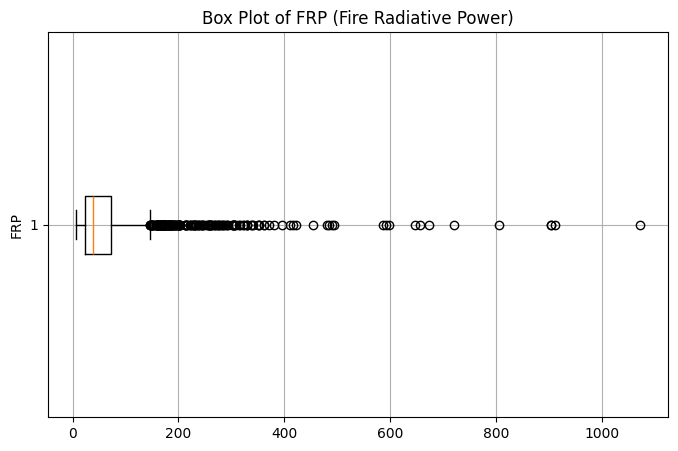

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
plt.figure(figsize=(8, 5))
plt.boxplot(fire_df['frp'].dropna(), vert=False)  # dropna() removes missing values, if any.

plt.title('Box Plot of FRP (Fire Radiative Power)')
plt.ylabel('FRP')
plt.grid(True)

plt.show()

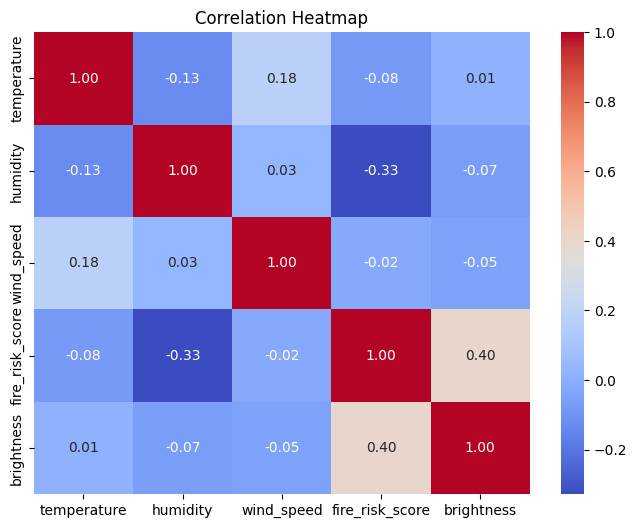

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = fire_df[['temperature', 'humidity', 'wind_speed', 'fire_risk_score','brightness']]

# Compute correlation
corr = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

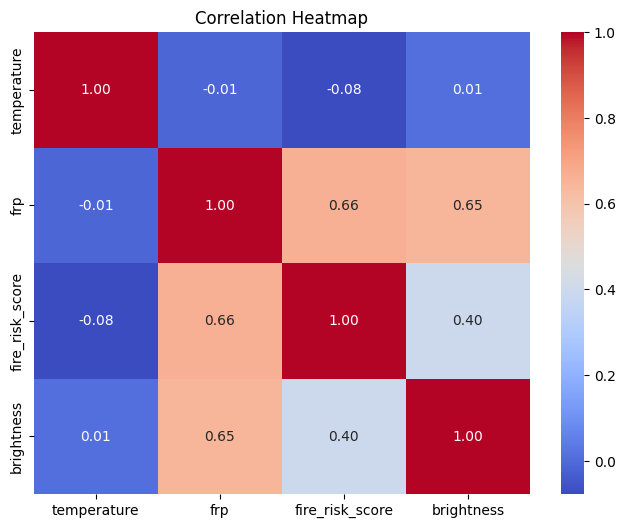

In [ ]:
# Heatmap to identify the correlation between the variables
corr_df = fire_df[['temperature','frp', 'fire_risk_score','brightness']]

# Compute correlation
corr = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# To check which are is more prone to the fire
import plotly.express as px
px.scatter_geo(fire_df, lat='latitude', lon='longitude', color='fire_risk_score', title="Geographic Fire Risk")

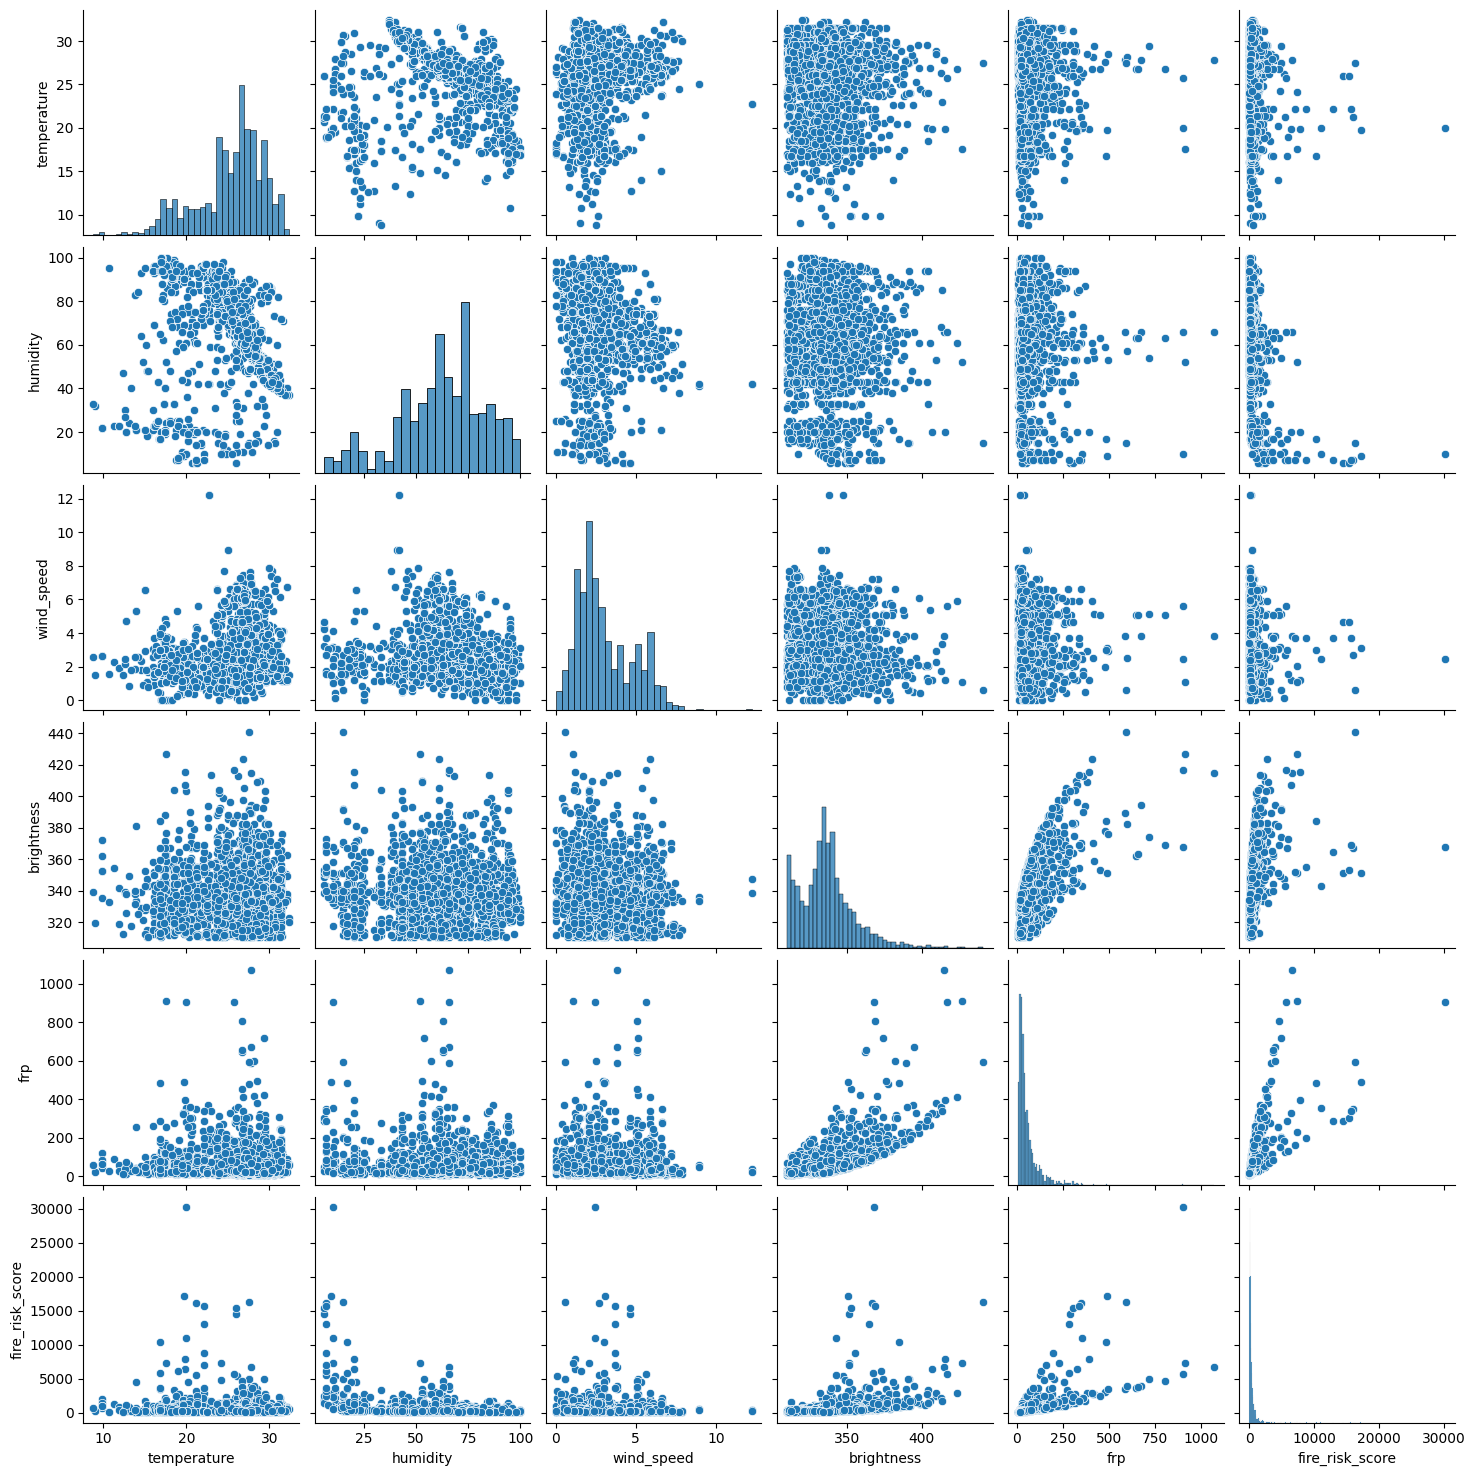

In [ ]:
# pairplot between the attributes to check the relation between them.
sns.pairplot(fire_df[['temperature', 'humidity', 'wind_speed', 'brightness', 'frp', 'fire_risk_score']])

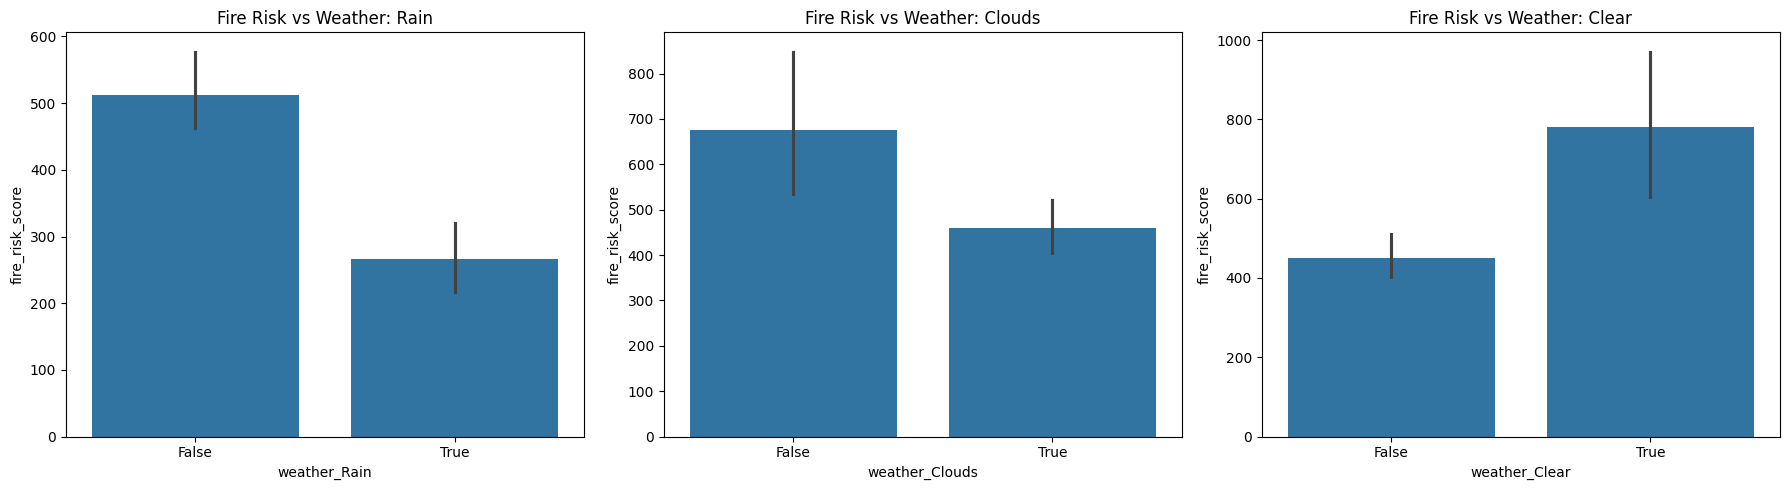

In [ ]:
# To check the relation between the fire_risk_score and categorical attributes
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # clearly a 1x3 grid with proper width

# Plot 1: Weather Rain
sns.barplot(data=fire_df, x='weather_Rain', y='fire_risk_score', ax=axes[0])
axes[0].set_title("Fire Risk vs Weather: Rain")

# Plot 2: Weather Clouds
sns.barplot(data=fire_df, x='weather_Clouds', y='fire_risk_score', ax=axes[1])
axes[1].set_title("Fire Risk vs Weather: Clouds")

# Plot 3: Weather Clear
sns.barplot(data=fire_df, x='weather_Clear', y='fire_risk_score', ax=axes[2])
axes[2].set_title("Fire Risk vs Weather: Clear")

# Adjust clearly the layout
plt.tight_layout()
plt.show()

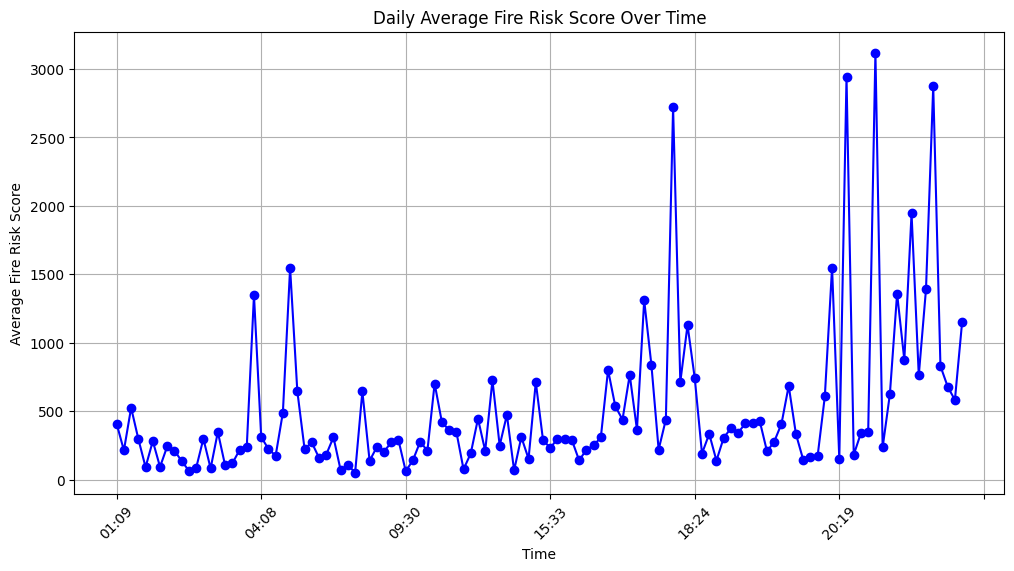

In [ ]:
import matplotlib.pyplot as plt


daily_risk = fire_df.groupby('acq_time')['fire_risk_score'].mean()

# Enhanced plot
plt.figure(figsize=(12, 6))
daily_risk.plot(marker='o', linestyle='-', color='blue')

plt.title('Daily Average Fire Risk Score Over Time')
plt.xlabel('Time')
plt.ylabel('Average Fire Risk Score')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

## Model Training

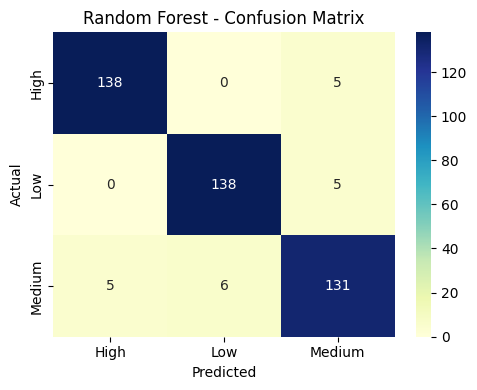

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[23:43:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[23:43:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[23:43:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[23:43:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[23:43:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[23:43:25] WARNING: /workspace

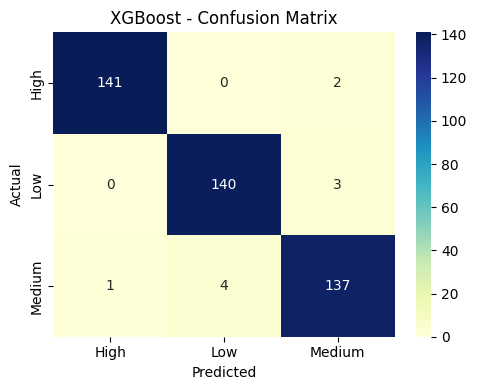

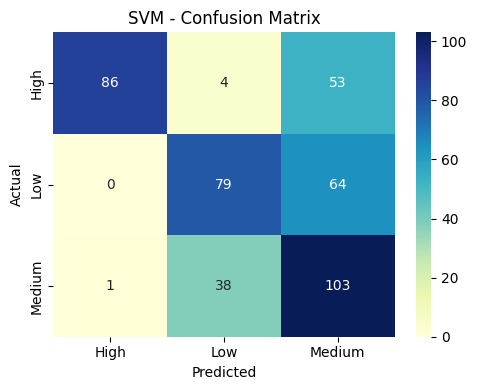

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.11/dist-packages/sklearn/

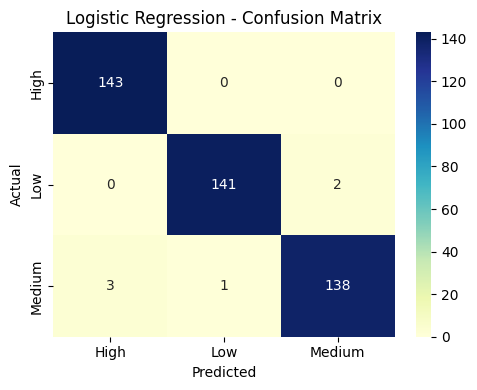

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load feature-engineered data
df = pd.read_csv("./Wildfire-Risk-Analysis-System/wildfire-risk-analysis/data/processed/fires_features.csv")

# Label encode target
df["risk_level"] = pd.qcut(df["fire_risk_score"], q=3, labels=["Low", "Medium", "High"])
label_encoder = LabelEncoder()
df["risk_encoded"] = label_encoder.fit_transform(df["risk_level"])

# Features and target
feature_cols = ['temperature', 'humidity', 'wind_speed', 'brightness', 'frp',
                'wind_factor', 'is_daytime'] + [col for col in df.columns if col.startswith("weather_")]

X = df[feature_cols]
y = df["risk_encoded"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50, max_depth=4, eval_metric='mlogloss', use_label_encoder=False),
    "SVM": SVC(kernel='rbf', probability=True),
    "Logistic Regression": LogisticRegression(max_iter=500)
}

# Results list
results = []

model_objects = {}
model_preds = {}
model_probs = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    # Store model, preds, and probs for future use
    model_objects[name] = model
    model_preds[name] = preds
    model_probs[name] = probs

    # Evaluation report
    report = classification_report(y_test, preds, output_dict=True)
    cm = confusion_matrix(y_test, preds, labels=[0, 1, 2])

    # Cross-validation
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (avg)": report["macro avg"]["precision"],
        "Recall (avg)": report["macro avg"]["recall"],
        "F1-score (avg)": report["macro avg"]["f1-score"],
        "CV Accuracy (mean)": np.mean(cv_scores),
        "CV Accuracy (std)": np.std(cv_scores)
    })

    # Confusion matrix plot
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()



In [ ]:
# Show results
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (avg),Recall (avg),F1-score (avg),CV Accuracy (mean),CV Accuracy (std)
0,Random Forest,0.950935,0.950815,0.950868,0.950834,0.947618,0.008435
1,XGBoost,0.976636,0.976656,0.976608,0.976624,0.972872,0.003171
2,SVM,0.626168,0.703193,0.626399,0.638457,0.611811,0.029577
3,Logistic Regression,0.985981,0.986041,0.985948,0.985939,0.984102,0.009506


## Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_proba=None):
    results = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1 Score': f1_score(y_true, y_pred, average='weighted'),
    }
    if y_proba is not None:
        try:
            results['ROC AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr')
        except:
            results['ROC AUC'] = None
    return results


In [ ]:
rf_results = evaluate_model(y_test, model_preds['Random Forest'], model_probs['Random Forest'])
xgb_results = evaluate_model(y_test, model_preds['XGBoost'], model_probs['XGBoost'])
svm_results = evaluate_model(y_test, model_preds['SVM'], model_probs['SVM'])
lr_results = evaluate_model(y_test, model_preds['Logistic Regression'], model_probs['Logistic Regression'])

pd.DataFrame(
    [rf_results, xgb_results, svm_results, lr_results],
    index=['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression']
)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.950935,0.950866,0.950935,0.950893,0.994740
XGBoost,0.976636,0.976684,0.976636,0.976652,0.998106
SVM,0.626168,0.703742,0.626168,0.638619,0.884653
Logistic Regression,0.985981,0.986042,0.985981,0.985956,0.999475


In [ ]:
import joblib

# Save best model (change key to whichever model you choose)
best_model = model_objects['Random Forest']
joblib.dump(best_model, 'best_model.pkl')

# Save the label encoder (for decoding predictions later)
joblib.dump(label_encoder, 'label_encoder.pkl')


['label_encoder.pkl']

Wildfire Risk Prediction Function, it loads the saved model and predicts the risk level for new data

In [ ]:
def predict_wildfire_risk(input_features, model_path='best_model.pkl', encoder_path='label_encoder.pkl'):
    import joblib
    import numpy as np

    # Load model and label encoder
    model = joblib.load(model_path)
    label_encoder = joblib.load(encoder_path)

    # Make prediction
    pred = model.predict([input_features])[0]
    proba = model.predict_proba([input_features])[0]

    # Decode prediction
    risk_label = label_encoder.inverse_transform([pred])[0]

    return {
        "Predicted Class": int(pred),
        "Risk Level": risk_label,
        "Probabilities": dict(zip(label_encoder.classes_, proba.round(3)))
    }


row of sample data to simulate input from a frontend or API:

In [ ]:
sample_input = X_test.iloc[0].tolist()

# Run prediction
predict_wildfire_risk(sample_input)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



{'Predicted Class': 1,
 'Risk Level': 'Low',
 'Probabilities': {'High': np.float64(0.0),
  'Low': np.float64(0.98),
  'Medium': np.float64(0.02)}}

Visualize Feature Importance: gives insights into which features drive model decisions.



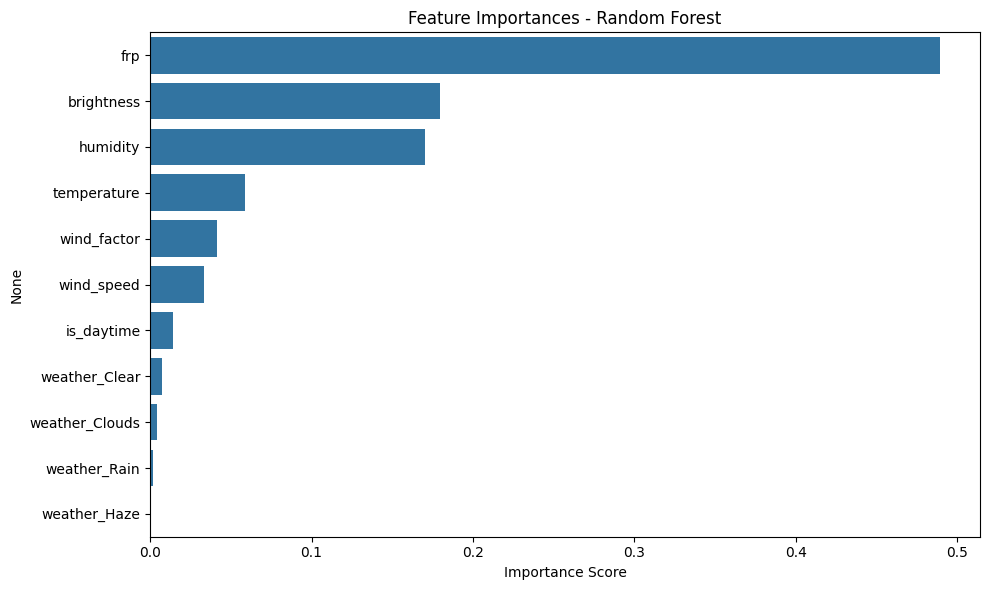

In [ ]:
importances = best_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices])
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


Save Feature Columns

In [ ]:
import json
with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f)


Step-by-Step: Streamlit Wildfire Risk Predictor
📁 File Structure
You’ll need:

wildfire_app/
├── app.py
├── best_model.pkl
├── label_encoder.pkl
├── feature_columns.json



Step 1: Save Model Files (you may already have these)
Make sure you've saved:

In [ ]:
import joblib
import json

joblib.dump(best_model, '/content/best_model.pkl')
joblib.dump(label_encoder, '/content/label_encoder.pkl')

# Save feature column names
with open('/content/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)


Step 2: Create app.py

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.5 MB/s eta 0:00:00


streamlit run path_to_your_app.py

In [ ]:
import streamlit as st
import joblib
import json
import numpy as np

# Load model and metadata
model = joblib.load("best_model.pkl")
label_encoder = joblib.load("label_encoder.pkl")

with open("feature_columns.json", "r") as f:
    feature_columns = json.load(f)

st.set_page_config(page_title="Wildfire Risk Predictor", layout="centered")
st.title("🔥 Wildfire Risk Predictor")
st.markdown("Enter wildfire-related data below to predict the risk level.")

# User input for features
user_input = []
for feature in feature_columns:
    if "weather_" in feature:
        val = st.selectbox(f"{feature}", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    elif feature == "is_daytime":
        val = st.selectbox("Is it daytime?", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    else:
        val = st.number_input(f"{feature}", value=0.0)
    user_input.append(val)

if st.button("Predict Risk Level"):
    pred = model.predict([user_input])[0]
    proba = model.predict_proba([user_input])[0]
    risk_label = label_encoder.inverse_transform([pred])[0]

    st.success(f"Predicted Risk Level: **{risk_label}**")

    st.subheader("Prediction Probabilities")
    st.bar_chart({
        label: [proba[i]] for i, label in enumerate(label_encoder.classes_)
    })


2025-04-15 23:54:24.863 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-15 23:54:24.872 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-15 23:54:25.349 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-15 23:54:25.360 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-15 23:54:25.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-15 23:54:25.366 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-15 23:54:25.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

cd wildfire_app

In [ ]:

streamlit run app.py
